# FinanceBench Retrieval Benchmark Audit

Notebook nay kiem tra qua trinh bien FinanceBench QA benchmark thanh retrieval benchmark.

Muc tieu:
- Doc benchmark goc `financebench_open_source.jsonl`.
- Doc retrieval benchmark da tao: `queries.jsonl`, `qrels.jsonl`, `unmatched_evidence.jsonl`, `mapping_report.json`.
- Visual so mau, so evidence moi mau, so qrels moi query, phuong phap match.
- Doi chieu benchmark goc voi benchmark retrieval de xem mapping co hop ly khong.

Luu y: FinanceBench khong co chunk ground truth. `qrels.jsonl` la ground truth suy ra bang cach map `evidence_text` / `evidence_page_num` vao chunks cua he thong.

In [50]:
from pathlib import Path
import json
import re
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path('..').resolve()
FINANCEBENCH_PATH = ROOT / 'benchmark/financebench/data/financebench_open_source.jsonl'
CHUNKS_PATH = ROOT / 'outputs/financebench_eval_bge/chunks.jsonl'
QRELS_DIR = ROOT / 'outputs/financebench_eval_bge/qrels'
QUERIES_PATH = QRELS_DIR / 'queries.jsonl'
QRELS_PATH = QRELS_DIR / 'qrels.jsonl'
UNMATCHED_PATH = QRELS_DIR / 'unmatched_evidence.jsonl'
MAPPING_REPORT_PATH = QRELS_DIR / 'mapping_report.json'

pd.set_option('display.max_colwidth', 160)

In [51]:
def find_project_root(start: Path) -> Path:
    start = start.resolve()
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / 'benchmark/financebench/data/financebench_open_source.jsonl').exists():
            return candidate
    raise FileNotFoundError('Cannot find project root from current working directory')

def load_jsonl(path: Path) -> list[dict]:
    if not path.exists() or path.stat().st_size == 0:
        return []
    rows = []
    with path.open('r', encoding='utf-8') as f:
        for line in f:
            if line.strip():
                rows.append(json.loads(line))
    return rows

def count_jsonl(path: Path) -> int:
    if not path.exists() or path.stat().st_size == 0:
        return 0
    with path.open('r', encoding='utf-8') as f:
        return sum(1 for line in f if line.strip())

def load_chunks_by_ids(path: Path, wanted_ids: set[str]) -> list[dict]:
    # Stream chunks.jsonl and keep only chunks referenced by qrels.
    # This avoids loading the full semantic chunk file into notebook memory.
    if not path.exists() or not wanted_ids:
        return []
    rows = []
    with path.open('r', encoding='utf-8') as f:
        for line in f:
            if not line.strip():
                continue
            row = json.loads(line)
            cid = row.get('chunk_id') or row.get('id')
            if cid in wanted_ids:
                rows.append(row)
    return rows

def norm_text(text: str) -> str:
    text = str(text or '').lower().replace('\u00a0', ' ')
    text = text.replace('???', '-').replace('?', '-').replace('?', '-')
    text = re.sub(r'[^a-z0-9$%.\-()]+', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

def doc_key(value) -> str:
    if value is None:
        return ''
    return Path(str(value).replace('\\', '/')).stem.lower()

def chunk_text(row: dict) -> str:
    return str(row.get('text') or row.get('summary') or '')

def chunk_doc(row: dict) -> str:
    for key in ['doc_name', 'source_doc', 'source_pdf', 'source_html']:
        if row.get(key):
            return doc_key(row.get(key))
    return ''

def page_range(row: dict):
    start = row.get('page_start', row.get('page'))
    end = row.get('page_end', row.get('page'))
    try:
        start = int(start) if start is not None else None
        end = int(end) if end is not None else start
    except (TypeError, ValueError):
        return None, None
    return start, end

def page_overlap(row: dict, page) -> bool:
    if page is None:
        return False
    start, end = page_range(row)
    return start is not None and end is not None and start <= int(page) <= end

def token_recall(needle: str, haystack: str) -> float:
    n = set(re.findall(r'[a-z0-9$%.\-()]+', norm_text(needle)))
    h = set(re.findall(r'[a-z0-9$%.\-()]+', norm_text(haystack)))
    return len(n & h) / len(n) if n else 0.0

In [52]:
ROOT = find_project_root(Path.cwd())
FINANCEBENCH_PATH = ROOT / 'benchmark/financebench/data/financebench_open_source.jsonl'
CHUNKS_PATH = ROOT / 'outputs/financebench_eval_bge/chunks.jsonl'
QRELS_DIR = ROOT / 'outputs/financebench_eval_bge/qrels'
QUERIES_PATH = QRELS_DIR / 'queries.jsonl'
QRELS_PATH = QRELS_DIR / 'qrels.jsonl'
UNMATCHED_PATH = QRELS_DIR / 'unmatched_evidence.jsonl'
MAPPING_REPORT_PATH = QRELS_DIR / 'mapping_report.json'

samples = load_jsonl(FINANCEBENCH_PATH)
queries = load_jsonl(QUERIES_PATH)
qrels = load_jsonl(QRELS_PATH)
unmatched = load_jsonl(UNMATCHED_PATH)
mapping_report = json.loads(MAPPING_REPORT_PATH.read_text(encoding='utf-8')) if MAPPING_REPORT_PATH.exists() else {}

wanted_chunk_ids = {row['chunk_id'] for row in qrels}
chunks = load_chunks_by_ids(CHUNKS_PATH, wanted_chunk_ids)
chunk_file_count = mapping_report.get('chunks') or count_jsonl(CHUNKS_PATH)

samples_df = pd.DataFrame(samples)
chunks_df = pd.DataFrame(chunks)
queries_df = pd.DataFrame(queries)
qrels_df = pd.DataFrame(qrels)
unmatched_df = pd.DataFrame(unmatched)

print('Project root:', ROOT)
print('Full chunk file rows:', chunk_file_count)
print('Loaded qrel chunks:', len(chunks), '/', len(wanted_chunk_ids))
mapping_report

Project root: D:\Project\BTL-NLP
Full chunk file rows: 9927
Loaded qrel chunks: 191 / 191


{'questions': 150,
 'chunks': 9927,
 'evidence_rows': 189,
 'qrels': 258,
 'unmatched_evidence': 0,
 'docs_with_chunks': 84,
 'evidence_rows_without_doc_chunks': 0,
 'match_method_counts': {'fuzzy_text': 192, 'exact_text': 66},
 'settings': {'fuzzy_token_threshold': 0.6,
  'fuzzy_sequence_threshold': 0.18,
  'max_fuzzy_matches': 5,
  'use_page_fallback': True,
  'evidence_page_base': 0}}

## 1. Benchmark goc: so mau va evidence moi mau

In [53]:
evidence_rows = []
for sample in samples:
    qid = str(sample['financebench_id'])
    for evidence_index, ev in enumerate(sample.get('evidence') or []):
        evidence_rows.append({
            'query_id': qid,
            'evidence_index': evidence_index,
            'doc_name': sample.get('doc_name'),
            'evidence_doc_name': doc_key(ev.get('evidence_doc_name') or ev.get('doc_name') or sample.get('doc_name')),
            'evidence_page_original': ev.get('evidence_page_num'),
            'evidence_page_one_indexed': int(ev['evidence_page_num']) + 1 if ev.get('evidence_page_num') is not None else None,
            'evidence_text': ev.get('evidence_text') or '',
            'question': sample.get('question'),
        })
evidence_df = pd.DataFrame(evidence_rows)

summary = {
    'financebench_samples': len(samples_df),
    'queries': len(queries_df),
    'evidence_rows': len(evidence_df),
    'chunks_total_in_file': chunk_file_count,
    'qrel_chunks_loaded': len(chunks_df),
    'qrels': len(qrels_df),
    'unmatched_evidence': len(unmatched_df),
    'unique_docs_in_evidence': evidence_df['evidence_doc_name'].nunique(),
}
summary

{'financebench_samples': 150,
 'queries': 150,
 'evidence_rows': 189,
 'chunks_total_in_file': 9927,
 'qrel_chunks_loaded': 191,
 'qrels': 258,
 'unmatched_evidence': 0,
 'unique_docs_in_evidence': 84}

count    150.000000
mean       1.260000
std        0.497376
min        1.000000
25%        1.000000
50%        1.000000
75%        1.000000
max        3.000000
Name: evidence_count, dtype: float64

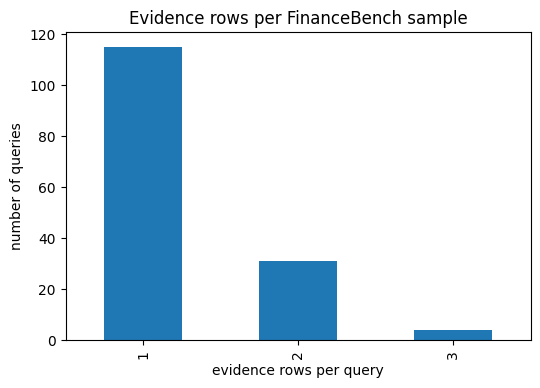

In [54]:
ev_per_query = evidence_df.groupby('query_id').size().rename('evidence_count').reset_index()
display(ev_per_query['evidence_count'].describe())

ax = ev_per_query['evidence_count'].value_counts().sort_index().plot(kind='bar', figsize=(6, 4), title='Evidence rows per FinanceBench sample')
ax.set_xlabel('evidence rows per query')
ax.set_ylabel('number of queries')
plt.show()

## 2. Doi chieu queries.jsonl voi FinanceBench goc

In [55]:
orig_queries = samples_df[['financebench_id', 'question', 'answer', 'doc_name', 'company']].rename(columns={'financebench_id': 'query_id'})
merged_queries = orig_queries.merge(queries_df, on='query_id', how='outer', suffixes=('_orig', '_retrieval'), indicator=True)
query_checks = {
    'missing_from_queries_jsonl': int((merged_queries['_merge'] == 'left_only').sum()),
    'extra_in_queries_jsonl': int((merged_queries['_merge'] == 'right_only').sum()),
    'question_mismatch': int((merged_queries['question_orig'] != merged_queries['question_retrieval']).fillna(False).sum()),
}
query_checks

{'missing_from_queries_jsonl': 0,
 'extra_in_queries_jsonl': 0,
 'question_mismatch': 0}

## 3. Doi chieu evidence goc voi qrels

In [56]:
qrel_ev = qrels_df.groupby(['query_id', 'evidence_index']).agg(
    qrel_count=('chunk_id', 'count'),
    match_methods=('match_method', lambda x: ','.join(sorted(set(x)))),
).reset_index() if not qrels_df.empty else pd.DataFrame(columns=['query_id', 'evidence_index', 'qrel_count', 'match_methods'])

evidence_audit = evidence_df.merge(qrel_ev, on=['query_id', 'evidence_index'], how='left')
evidence_audit['qrel_count'] = evidence_audit['qrel_count'].fillna(0).astype(int)
evidence_audit['is_matched'] = evidence_audit['qrel_count'] > 0

coverage = {
    'evidence_rows': len(evidence_audit),
    'matched_evidence_rows': int(evidence_audit['is_matched'].sum()),
    'unmatched_evidence_rows': int((~evidence_audit['is_matched']).sum()),
    'evidence_coverage': float(evidence_audit['is_matched'].mean()) if len(evidence_audit) else None,
}
coverage

{'evidence_rows': 189,
 'matched_evidence_rows': 189,
 'unmatched_evidence_rows': 0,
 'evidence_coverage': 1.0}

count    189.000000
mean       1.365079
std        0.691166
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        5.000000
Name: qrel_count, dtype: float64

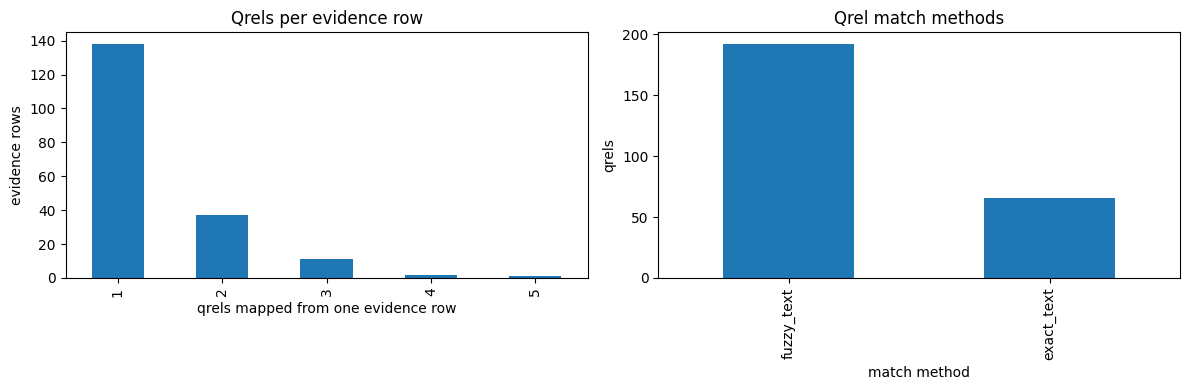

In [57]:
display(evidence_audit['qrel_count'].describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
evidence_audit['qrel_count'].value_counts().sort_index().plot(kind='bar', ax=axes[0], title='Qrels per evidence row')
axes[0].set_xlabel('qrels mapped from one evidence row')
axes[0].set_ylabel('evidence rows')
qrels_df['match_method'].value_counts().plot(kind='bar', ax=axes[1], title='Qrel match methods')
axes[1].set_xlabel('match method')
axes[1].set_ylabel('qrels')
plt.tight_layout()
plt.show()

## 4. Kiem tra qrels co dung document/page/evidence khong

In [58]:
chunk_lookup = {row.get('chunk_id') or row.get('id'): row for row in chunks}
audit_rows = []
for row in qrels:
    chunk = chunk_lookup.get(row['chunk_id'], {})
    ev = evidence_df[(evidence_df['query_id'] == row['query_id']) & (evidence_df['evidence_index'] == row['evidence_index'])]
    ev_text = ev.iloc[0]['evidence_text'] if len(ev) else ''
    ctext = chunk_text(chunk)
    audit_rows.append({
        **row,
        'chunk_doc_name': chunk_doc(chunk),
        'doc_match': chunk_doc(chunk) == row.get('evidence_doc_name'),
        'page_match': page_overlap(chunk, row.get('evidence_page')),
        'exact_contains_now': norm_text(ev_text) in norm_text(ctext) if ev_text else False,
        'computed_token_recall': token_recall(ev_text, ctext),
        'chunk_page_start': page_range(chunk)[0],
        'chunk_page_end': page_range(chunk)[1],
        'chunk_text_preview': ctext[:300],
    })
qrel_audit_df = pd.DataFrame(audit_rows)

qrel_quality = {
    'qrels': len(qrel_audit_df),
    'doc_match_rate': float(qrel_audit_df['doc_match'].mean()) if len(qrel_audit_df) else None,
    'page_match_rate': float(qrel_audit_df['page_match'].mean()) if len(qrel_audit_df) else None,
    'exact_contains_rate': float(qrel_audit_df['exact_contains_now'].mean()) if len(qrel_audit_df) else None,
    'avg_token_recall': float(qrel_audit_df['computed_token_recall'].mean()) if len(qrel_audit_df) else None,
}
qrel_quality

{'qrels': 258,
 'doc_match_rate': 1.0,
 'page_match_rate': 0.7790697674418605,
 'exact_contains_rate': 0.2596899224806202,
 'avg_token_recall': 0.8886985921410613}

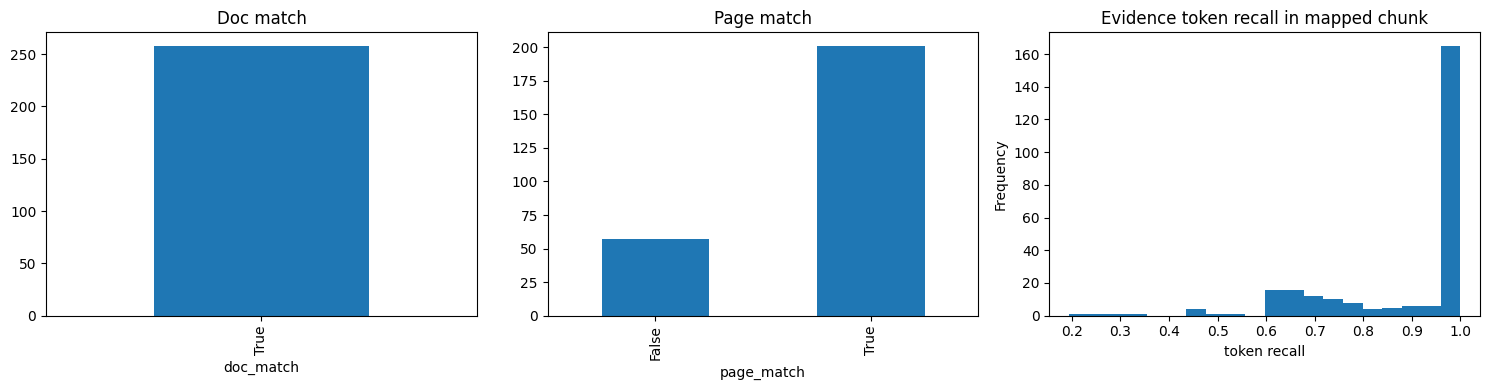

In [59]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
qrel_audit_df['doc_match'].value_counts().sort_index().plot(kind='bar', ax=axes[0], title='Doc match')
qrel_audit_df['page_match'].value_counts().sort_index().plot(kind='bar', ax=axes[1], title='Page match')
qrel_audit_df['computed_token_recall'].plot(kind='hist', bins=20, ax=axes[2], title='Evidence token recall in mapped chunk')
axes[2].set_xlabel('token recall')
plt.tight_layout()
plt.show()

## 5. Moi query phu hop voi cac chunk nao

In [60]:
query_chunk_rows = []
for row in qrels:
    chunk = chunk_lookup.get(row['chunk_id'], {})
    sample = samples_df[samples_df['financebench_id'] == row['query_id']]
    query_chunk_rows.append({
        'query_id': row['query_id'],
        'question': sample.iloc[0]['question'] if len(sample) else '',
        'answer': sample.iloc[0]['answer'] if len(sample) else '',
        'evidence_index': row.get('evidence_index'),
        'chunk_id': row['chunk_id'],
        'chunk_doc_name': chunk_doc(chunk),
        'chunk_page_start': page_range(chunk)[0],
        'chunk_page_end': page_range(chunk)[1],
        'evidence_page': row.get('evidence_page'),
        'match_method': row.get('match_method'),
        'match_score': row.get('match_score'),
        'token_recall': row.get('token_recall'),
        'sequence_ratio': row.get('sequence_ratio'),
        'chunk_text_preview': chunk_text(chunk)[:300],
    })

query_chunk_df = pd.DataFrame(query_chunk_rows)
query_chunk_df.head(20)

,query_id,question,answer,evidence_index,chunk_id,chunk_doc_name,chunk_page_start,chunk_page_end,evidence_page,match_method,match_score,token_recall,sequence_ratio,chunk_text_preview
0,financebench_id_03029,What is the FY2018 capital expenditure amount (in USD millions) for 3M? Give a response to the question by relying on the details shown in the cash flow sta...,$1577.00,0,fb_bge_text_73ecbee8a3a43b44,3m_2018_10k,54,61,60,fuzzy_text,0.819741,0.995671,0.291951,Definition and Limitations of Internal Control over Financial Reporting A company’s internal control over financial reporting is a process designed to provi...
1,financebench_id_04672,Assume that you are a public equities analyst. Answer the following question by primarily using information that is shown in the balance sheet: what is the ...,$8.70,0,fb_bge_text_73ecbee8a3a43b44,3m_2018_10k,54,61,58,fuzzy_text,0.818714,1.000000,0.274854,Definition and Limitations of Internal Control over Financial Reporting A company’s internal control over financial reporting is a process designed to provi...
2,financebench_id_00499,Is 3M a capital-intensive business based on FY2022 data?,"No, the company is managing its CAPEX and Fixed Assets pretty efficiently, which is evident from below key metrics:\nCAPEX/Revenue Ratio: 5.1%\nFixed assets...",0,fb_bge_text_bd0e49da1f5a46c4,3m_2022_10k,47,53,48,exact_text,1.000000,NaN,NaN,"In December 2022, the Company committed to a plan to exit per- and polyfluoroalkyl substance (PFAS) manufacturing by the end of 2025. As a result, the Compa..."
3,financebench_id_00499,Is 3M a capital-intensive business based on FY2022 data?,"No, the company is managing its CAPEX and Fixed Assets pretty efficiently, which is evident from below key metrics:\nCAPEX/Revenue Ratio: 5.1%\nFixed assets...",1,fb_bge_text_bd0e49da1f5a46c4,3m_2022_10k,47,53,50,fuzzy_text,0.777648,1.000000,0.110590,"In December 2022, the Company committed to a plan to exit per- and polyfluoroalkyl substance (PFAS) manufacturing by the end of 2025. As a result, the Compa..."
4,financebench_id_00499,Is 3M a capital-intensive business based on FY2022 data?,"No, the company is managing its CAPEX and Fixed Assets pretty efficiently, which is evident from below key metrics:\nCAPEX/Revenue Ratio: 5.1%\nFixed assets...",2,fb_bge_text_bd0e49da1f5a46c4,3m_2022_10k,47,53,52,fuzzy_text,0.767340,1.000000,0.069361,"In December 2022, the Company committed to a plan to exit per- and polyfluoroalkyl substance (PFAS) manufacturing by the end of 2025. As a result, the Compa..."
5,financebench_id_00499,Is 3M a capital-intensive business based on FY2022 data?,"No, the company is managing its CAPEX and Fixed Assets pretty efficiently, which is evident from below key metrics:\nCAPEX/Revenue Ratio: 5.1%\nFixed assets...",2,fb_bge_text_7a89c7766ae1524b,3m_2022_10k,38,40,52,fuzzy_text,0.631783,0.776860,0.196554,"Current portion of long-term debt increased as upcoming debt maturities now considered current were partially offset by the bond maturities in 2022, while a..."
6,financebench_id_01226,"What drove operating margin change as of FY2022 for 3M? If operating margin is not a useful metric for a company like this, then please state that and expla...",Operating Margin for 3M in FY2022 has decreased by 1.7% primarily due to: \n-Decrease in gross Margin\n-mostly one-off charges including Combat Arms Earplug...,0,fb_bge_text_a0bf9a59178f8c22,3m_2022_10k,27,28,27,exact_text,1.000000,NaN,NaN,"Cost of Sales: Cost of sales, measured as a percent of sales, increased in 2022 when compared to the same period last year. Increases were primarily due to ..."
7,financebench_id_01865,"If we exclude the impact of M&A, which segment has dragged down 3M's overall growth in 2022?",The consumer segment shrunk by 0.9% organically.,0,fb_bge_text_8290a18a056cc773,3m_2022_10k,24,26,25,fuzzy_text,0.773083,1.000000,0.092333,"Table of Contents Operating Income (Loss) (Dollars in millions, except per share amounts) Safety and Industrial Safet

count    150.000000
mean       1.533333
std        0.872139
min        1.000000
25%        1.000000
50%        1.000000
75%        2.000000
max        5.000000
Name: relevant_chunk_count, dtype: float64

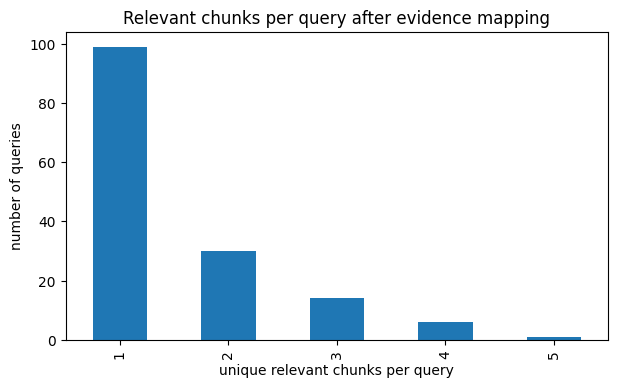

,query_id,relevant_chunk_count,qrel_count,evidence_count,match_methods,pages,question,answer,doc_name
92,financebench_id_01936,5,5,1,fuzzy_text,"5,14,20,23,41",What is the nature & purpose of AMCOR's restructuring liability as oF Q2 of FY2023 close?,87% of the total restructuring liability is related Employee liabilities.,AMCOR_2023Q2_10Q
129,financebench_id_04735,4,4,2,fuzzy_text,"58,59,60,63",You are an investment banker and your only resource(s) to answer the following question is (are): the statement of financial position and the cash flow stat...,0.66,ADOBE_2015_10K
38,financebench_id_00705,4,4,1,fuzzy_text,"1,2,9,85","By how much did Pepsico increase its unsecured five year revolving credit agreement on May 26, 2023?","$400,000,000 increase.",PEPSICO_2023_8K_dated-2023-05-30
62,financebench_id_01107,4,5,3,"exact_text,fuzzy_text","51,172,173,174","Has CVS Health reported any materially important ongoing legal battles from 2022, 2021 and 2020?","Yes, CVS Health has been involved in multiple ongoing legal battles. Some notable legal dispute areas for CVS are: (1) usual and customary pricing litigatio...",CVSHEALTH_2022_10K
52,financebench_id_00882,4,4,1,fuzzy_text,"1,2,9,85","As of May 26, 2023, what is the total amount Pepsico may borrow under its unsecured revolving credit agreements?","Total amount Pepsico may borrow under unsecured revolving credit agreements = $8,400,000,000.",PEPSICO_2023_8K_dated-2023-05-30
120,financebench_id_04254,4,4,2,fuzzy_text,"62,83,88,136","Basing your judgments off of the cash flow statement and the income statement, what is American Water Works's FY2021 unadjusted operating income + depreciat...",$1832.00,AMERICANWATERWORKS_2021_10K
149,financebench_id_10499,4,5,2,fuzzy_text,"41,49,52,110",What is Kraft Heinz's FY2019 inventory turnover ratio? Inventory turnover ratio is defined as: (FY2019 COGS) / (average inventory between FY2018 and FY2019)...,6.25,KRAFTHEINZ_2019_10K
50,financebench_id_00839,3,3,1,fuzzy_text,"1,2,27",Does Foot Locker's new CEO have previous CEO experience in a similar company to Footlocker?,Yes. She was previous CEO of Ulta Beauty which means she had to manage a large retail company that has brick and mortar + online business. So yes she was a ...,FOOTLOCKER_2022_8K_dated_2022-08-19
85,financebench_id_01865,3,3,1,fuzzy_text,"24,30,32","If we exclude the impact of M&A, which segment has dragged down 3M's overall growth in 2022?",The consumer segment shrunk by 0.9% organically.,3M_2022_10K
71,financebench_id_01290,3,3,3,exact_text,"8,9,14",Who are the primary customers of Boeing as of FY2022?,Boeing's primary customers as of FY2022 are a limited number of commercial airlines and the US government. The US government accounted for 40% of Boeing's t...,BOEING_2022_10K


In [61]:
chunks_per_query = query_chunk_df.groupby('query_id').agg(
    relevant_chunk_count=('chunk_id', 'nunique'),
    qrel_count=('chunk_id', 'count'),
    evidence_count=('evidence_index', 'nunique'),
    match_methods=('match_method', lambda x: ','.join(sorted(set(x)))),
    pages=('chunk_page_start', lambda x: ','.join(map(str, sorted(set(x.dropna().astype(int)))))),
).reset_index()
chunks_per_query = chunks_per_query.merge(queries_df[['query_id', 'question', 'answer', 'doc_name']], on='query_id', how='left')

display(chunks_per_query['relevant_chunk_count'].describe())
ax = chunks_per_query['relevant_chunk_count'].value_counts().sort_index().plot(
    kind='bar', figsize=(7, 4), title='Relevant chunks per query after evidence mapping'
)
ax.set_xlabel('unique relevant chunks per query')
ax.set_ylabel('number of queries')
plt.show()

chunks_per_query.sort_values('relevant_chunk_count', ascending=False).head(20)

Bang `query_chunk_df` ben duoi la mapping chi tiet: moi query phu hop voi chunk nao, nam o page nao, va duoc gan bang `exact_text`, `fuzzy_text` hay `page_fallback`.

In [62]:
query_chunk_df.sort_values(['query_id', 'evidence_index', 'match_score'], ascending=[True, True, False]).head(100)

,query_id,question,answer,evidence_index,chunk_id,chunk_doc_name,chunk_page_start,chunk_page_end,evidence_page,match_method,match_score,token_recall,sequence_ratio,chunk_text_preview
123,financebench_id_00005,"Does Corning have positive working capital based on FY2022 data? If working capital is not a useful or relevant metric for this company, then please state t...",Yes. Corning had a positive working capital amount of $831 million by FY 2022 close. This answer considers only operating current assets and current liabili...,0,fb_bge_text_69893a3a34d81a85,corning_2022_10k,57,60,60,exact_text,1.000000,NaN,NaN,Critical Audit Matter The critical audit matter communicated below is a matter arising from the current period audit of the consolidated financial statement...
84,financebench_id_00070,"Does American Water Works have positive working capital based on FY2022 data? If working capital is not a useful or relevant metric for this company, then p...","No, American Water Works had negative working capital of -$1561M in FY 2022.",0,fb_bge_text_0c2020111b6d7c53,americanwaterworks_2022_10k,80,84,81,fuzzy_text,0.784562,1.000000,0.138247,Table of Contents Critical Audit Matters The critical audit matter communicated below is a matter arising from the current period audit of the consolidated ...
85,financebench_id_00070,"Does American Water Works have positive working capital based on FY2022 data? If working capital is not a useful or relevant metric for this company, then p...","No, American Water Works had negative working capital of -$1561M in FY 2022.",1,fb_bge_text_0c2020111b6d7c53,americanwaterworks_2022_10k,80,84,82,fuzzy_text,0.802328,1.000000,0.209312,Table of Contents Critical Audit Matters The critical audit matter communicated below is a matter arising from the current period audit of the consolidated ...
203,financebench_id_00080,"Does Paypal have positive working capital based on FY2022 data? If working capital is not a useful or relevant metric for this company, then please state th...",Yes. Paypal has a positive working capital of $ 1.6Bn as of FY2022 end.,0,fb_bge_text_d5ce9f9f22e26cf2,paypal_2022_10k,60,64,61,fuzzy_text,0.815466,1.000000,0.261864,Critical Audit Matters The critical audit matter communicated below is a matter arising from the current period audit of the consolidated financial statemen...
161,financebench_id_00206,Are JPM's gross margins historically consistent (not fluctuating more than roughly 2% each year)? If gross margins are not a relevant metric for a company l...,"Since JPM is a financial institution, gross margin is not a relevant metric.",0,fb_bge_text_b994d09e6453d6e2,jpmorgan_2022_10k,3,4,3,fuzzy_text,0.761814,0.959459,0.168876,"Overview JPMorgan Chase & Co. (“JPMorgan Chase” or the “Firm”, NYSE: JPM), a financial holding company incorporated under Delaware law in 1968, is a leading..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
131,financebench_id_01107,"Has CVS Health reported any materially important ongoing legal battles from 2022, 2021 and 2020?","Yes, CVS Health has been involved in multiple ongoing legal battles. Some notable legal dispute areas for CVS are: (1) usual and customary pricing litigatio...",0,fb_bge_text_29b39d94b9429e93,cvshealth_2022_10k,172,173,173,fuzzy_text,0.731110,0.974359,0.001361,"The Company’s total guaranty fund assessments liability was immaterial at both December 31, 2022 and 2021. Litigation and Regulatory Proceedings The Company..."
132,financebench_id_01107,"Has CVS Health reported any materially important ongoing legal battles from 2022, 2021 and 2020?","Yes, CVS Health has been involved in multiple ongoing legal battles. Some notable legal dispute areas for CVS are: (1) usual and customary pricing litigatio...",0,fb_bge_text_a7071db55879056d,cvshealth_2022_10k,51,52,173,fuzzy_text,0.462991,0.615385,0.005809,There can be no assurances that the Company will be successful in maintaining or improving its star ratings in future years. If our 

Neu muon xem rieng mot query:

In [63]:
QUERY_ID = chunks_per_query.sort_values('relevant_chunk_count', ascending=False).iloc[0]['query_id']
print('Selected query:', QUERY_ID)
display(queries_df[queries_df['query_id'] == QUERY_ID])
display(query_chunk_df[query_chunk_df['query_id'] == QUERY_ID].sort_values(['evidence_index', 'match_score'], ascending=[True, False]))

Selected query: financebench_id_01936


,query_id,question,answer,doc_name,company,question_type,question_reasoning
27,financebench_id_01936,What is the nature & purpose of AMCOR's restructuring liability as oF Q2 of FY2023 close?,87% of the total restructuring liability is related Employee liabilities.,AMCOR_2023Q2_10Q,Amcor,novel-generated,NaN


,query_id,question,answer,evidence_index,chunk_id,chunk_doc_name,chunk_page_start,chunk_page_end,evidence_page,match_method,match_score,token_recall,sequence_ratio,chunk_text_preview
49,financebench_id_01936,What is the nature & purpose of AMCOR's restructuring liability as oF Q2 of FY2023 close?,87% of the total restructuring liability is related Employee liabilities.,0,fb_bge_text_0c6ccbdde20f8c0b,amcor_2023q2_10q,14,17,15,fuzzy_text,0.776619,1.000000,0.106475,"The total net cash consideration received was $365 million and resulted in a net pre-tax net gain of $215 million, which included a reversal of a $90 millio..."
50,financebench_id_01936,What is the nature & purpose of AMCOR's restructuring liability as oF Q2 of FY2023 close?,87% of the total restructuring liability is related Employee liabilities.,0,fb_bge_text_b11288c0de7a2a76,amcor_2023q2_10q,23,26,15,fuzzy_text,0.508649,0.674419,0.011342,"On October 12, 2021, the Company contracted with Pacific Life Insurance Company to purchase a group annuity contract and to transfer $186 million of its pen..."
51,financebench_id_01936,What is the nature & purpose of AMCOR's restructuring liability as oF Q2 of FY2023 close?,87% of the total restructuring liability is related Employee liabilities.,0,fb_bge_text_d429be743075ff90,amcor_2023q2_10q,5,10,15,fuzzy_text,0.506924,0.674419,0.004438,Part I - Financial Information Item 1. Financial Statements (unaudited) Amcor plc and Subsidiaries Condensed Consolidated Statements of Income (Unaudited) T...
52,financebench_id_01936,What is the nature & purpose of AMCOR's restructuring liability as oF Q2 of FY2023 close?,87% of the total restructuring liability is related Employee liabilities.,0,fb_bge_text_5116547a817dd2cc,amcor_2023q2_10q,20,23,15,fuzzy_text,0.480165,0.627907,0.036938,"Commodity Risk Certain raw materials used in the Company's production processes are subject to price volatility caused by weather, supply conditions, politi..."
53,financebench_id_01936,What is the nature & purpose of AMCOR's restructuring liability as oF Q2 of FY2023 close?,87% of the total restructuring liability is related Employee liabilities.,0,fb_bge_text_acf90eaaa205d357,amcor_2023q2_10q,41,44,15,fuzzy_text,0.476091,0.627907,0.020642,"The effective tax rate for the six months ended December 31, 2022 decreased by 10.7 percentage points compared to the six months ended December 31, 2021, pr..."


## 6. Cac truong hop can xem lai

In [64]:
suspicious = qrel_audit_df[
    (~qrel_audit_df['doc_match']) |
    (~qrel_audit_df['page_match']) |
    ((qrel_audit_df['match_method'] == 'fuzzy_text') & (qrel_audit_df['computed_token_recall'] < 0.60))
].copy()
suspicious[['query_id', 'chunk_id', 'match_method', 'match_score', 'doc_match', 'page_match', 'computed_token_recall', 'evidence_doc_name', 'chunk_doc_name', 'evidence_page', 'chunk_page_start', 'chunk_page_end']].head(30)

,query_id,chunk_id,match_method,match_score,doc_match,page_match,computed_token_recall,evidence_doc_name,chunk_doc_name,evidence_page,chunk_page_start,chunk_page_end
5,financebench_id_00499,fb_bge_text_7a89c7766ae1524b,fuzzy_text,0.631783,True,False,0.776860,3m_2022_10k,3m_2022_10k,52,38,40
8,financebench_id_01865,fb_bge_text_156c338427fd0bfa,fuzzy_text,0.561758,True,False,0.742857,3m_2022_10k,3m_2022_10k,25,30,32
9,financebench_id_01865,fb_bge_text_fa9a2443abb21394,fuzzy_text,0.476498,True,False,0.628571,3m_2022_10k,3m_2022_10k,25,32,34
15,financebench_id_02987,fb_bge_text_6095cb2827ef1151,fuzzy_text,0.594136,True,False,0.658065,activisionblizzard_2019_10k,activisionblizzard_2019_10k,70,36,37
17,financebench_id_07966,fb_bge_text_6095cb2827ef1151,fuzzy_text,0.594136,True,False,0.658065,activisionblizzard_2019_10k,activisionblizzard_2019_10k,70,36,37
20,financebench_id_04735,fb_bge_text_067b325f0bff257a,fuzzy_text,0.427137,True,True,0.493927,adobe_2015_10k,adobe_2015_10k,59,59,60
22,financebench_id_04735,fb_bge_text_36190f64faeaa451,fuzzy_text,0.423785,True,True,0.475806,adobe_2015_10k,adobe_2015_10k,63,60,63
27,financebench_id_00438,fb_bge_text_b15656fd79ddee9c,fuzzy_text,0.511016,True,False,0.650000,adobe_2022_10k,adobe_2022_10k,54,42,45
30,financebench_id_01319,fb_bge_text_1a7c1b2f26b6f02e,fuzzy_text,0.695221,True,False,0.840237,aes_2022_10k,aes_2022_10k,132,85,87
35,financebench_id_10420,fb_bge_text_1a7c1b2f26b6f02e,fuzzy_text,0.667003,True,False,0.792553,aes_2022_10k,aes_2022_10k,132,85,87


In [65]:
if len(unmatched_df):
    display(unmatched_df.head(20))
else:
    print('No unmatched evidence rows.')

No unmatched evidence rows.


## Shell-style quick stats: qrels theo query

Cell nay thong ke nhanh tu `qrels.jsonl`: moi query relevant voi bao nhieu `chunk_id`, phan bo so chunk relevant, va top query co nhieu chunk relevant nhat.

In [66]:
from collections import Counter, defaultdict

qrels_path = QRELS_PATH
queries_path = QUERIES_PATH

qrels_raw = load_jsonl(qrels_path)
queries_raw = load_jsonl(queries_path)
query_lookup = {row['query_id']: row for row in queries_raw}

relevant_chunks_by_query = defaultdict(set)
qrels_by_query = Counter()
methods_by_query = defaultdict(set)

for row in qrels_raw:
    qid = row['query_id']
    relevant_chunks_by_query[qid].add(row['chunk_id'])
    qrels_by_query[qid] += 1
    methods_by_query[qid].add(row.get('match_method'))

distribution = Counter(len(chunk_ids) for chunk_ids in relevant_chunks_by_query.values())

print('Total queries:', len(queries_raw))
print('Queries with qrels:', len(relevant_chunks_by_query))
print('Total qrels:', len(qrels_raw))
print('Avg relevant chunks/query:', round(sum(len(v) for v in relevant_chunks_by_query.values()) / len(queries_raw), 4))
print('\nDistribution: relevant chunk_id count -> number of queries')
for chunk_count, query_count in sorted(distribution.items()):
    print(f'{chunk_count}: {query_count}')

rows = []
for qid, chunk_ids in relevant_chunks_by_query.items():
    query = query_lookup.get(qid, {})
    rows.append({
        'query_id': qid,
        'relevant_chunk_count': len(chunk_ids),
        'qrel_count': qrels_by_query[qid],
        'match_methods': ','.join(sorted(m for m in methods_by_query[qid] if m)),
        'question': query.get('question'),
        'answer': query.get('answer'),
    })

relevant_chunks_stats_df = pd.DataFrame(rows).sort_values('relevant_chunk_count', ascending=False)
display(relevant_chunks_stats_df.head(20))

Total queries: 150
Queries with qrels: 150
Total qrels: 258
Avg relevant chunks/query: 1.5333

Distribution: relevant chunk_id count -> number of queries
1: 99
2: 30
3: 14
4: 6
5: 1


,query_id,relevant_chunk_count,qrel_count,match_methods,question,answer
27,financebench_id_01936,5,5,fuzzy_text,What is the nature & purpose of AMCOR's restructuring liability as oF Q2 of FY2023 close?,87% of the total restructuring liability is related Employee liabilities.
10,financebench_id_04735,4,4,fuzzy_text,You are an investment banker and your only resource(s) to answer the following question is (are): the statement of financial position and the cash flow stat...,0.66
99,financebench_id_10499,4,5,fuzzy_text,What is Kraft Heinz's FY2019 inventory turnover ratio? Inventory turnover ratio is defined as: (FY2019 COGS) / (average inventory between FY2018 and FY2019)...,6.25
77,financebench_id_01107,4,5,"exact_text,fuzzy_text","Has CVS Health reported any materially important ongoing legal battles from 2022, 2021 and 2020?","Yes, CVS Health has been involved in multiple ongoing legal battles. Some notable legal dispute areas for CVS are: (1) usual and customary pricing litigatio..."
46,financebench_id_04254,4,4,fuzzy_text,"Basing your judgments off of the cash flow statement and the income statement, what is American Water Works's FY2021 unadjusted operating income + depreciat...",$1832.00
127,financebench_id_00882,4,4,fuzzy_text,"As of May 26, 2023, what is the total amount Pepsico may borrow under its unsecured revolving credit agreements?","Total amount Pepsico may borrow under unsecured revolving credit agreements = $8,400,000,000."
126,financebench_id_00705,4,4,fuzzy_text,"By how much did Pepsico increase its unsecured five year revolving credit agreement on May 26, 2023?","$400,000,000 increase."
67,financebench_id_03473,3,4,fuzzy_text,What is the FY2017 return on assets (ROA) for Coca Cola? ROA is defined as: FY2017 net income / (average total assets between FY2016 and FY2017). Round your...,0.01
22,financebench_id_01935,3,3,fuzzy_text,What was the key agenda of the AMCOR's 8k filing dated 1st July 2022?,"Amcor Finance (USA), Inc. and Amcor Flexibles North America, Inc., entered into supplemental indentures relating to Guaranteed Senior Notes due 2026 and 202..."
100,financebench_id_04412,3,4,fuzzy_text,We need to calculate a reasonable approximation (or exact number if possible) of a financial metric. Basing your judgment by information plainly provided in...,1.33
